# 05 — Dose Gap & Booster Impact
How booster uptake relates to overall vaccination coverage.

In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
with open(os.path.join("..", "data", "processed.pkl"), "rb") as f:
    df = pickle.load(f)

df["date"] = pd.to_datetime(df["date"])
print(f"Shape: {df.shape}")

Shape: (62980, 21)


## 1. Create booster uptake ratio

In [3]:
df["booster_uptake_ratio"] = (
    df["total_boosters_per_hundred"]
    .div(df["people_fully_vaccinated_per_hundred"])
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

df["booster_uptake_ratio"].describe()

count    62980.000000
mean         0.298971
std          0.388746
min          0.000000
25%          0.000000
50%          0.032974
75%          0.620826
max          1.804926
Name: booster_uptake_ratio, dtype: float64

## 2. Classify countries into high / low booster uptake

In [4]:
# use latest value per country to classify
latest = df.sort_values("date").groupby("location").last().reset_index()
median_ratio = latest["booster_uptake_ratio"].median()
print(f"Median booster uptake ratio: {median_ratio:.4f}")

# tag each country
latest["booster_group"] = np.where(
    latest["booster_uptake_ratio"] >= median_ratio,
    "High booster uptake", "Low booster uptake"
)
print(latest["booster_group"].value_counts())

# merge the group label back into the full df
country_group = latest[["location", "booster_group"]]
df = df.merge(country_group, on="location", how="left")

Median booster uptake ratio: 0.3764
booster_group
High booster uptake    111
Low booster uptake     110
Name: count, dtype: int64


## 3. Vaccination trends — high vs low booster groups

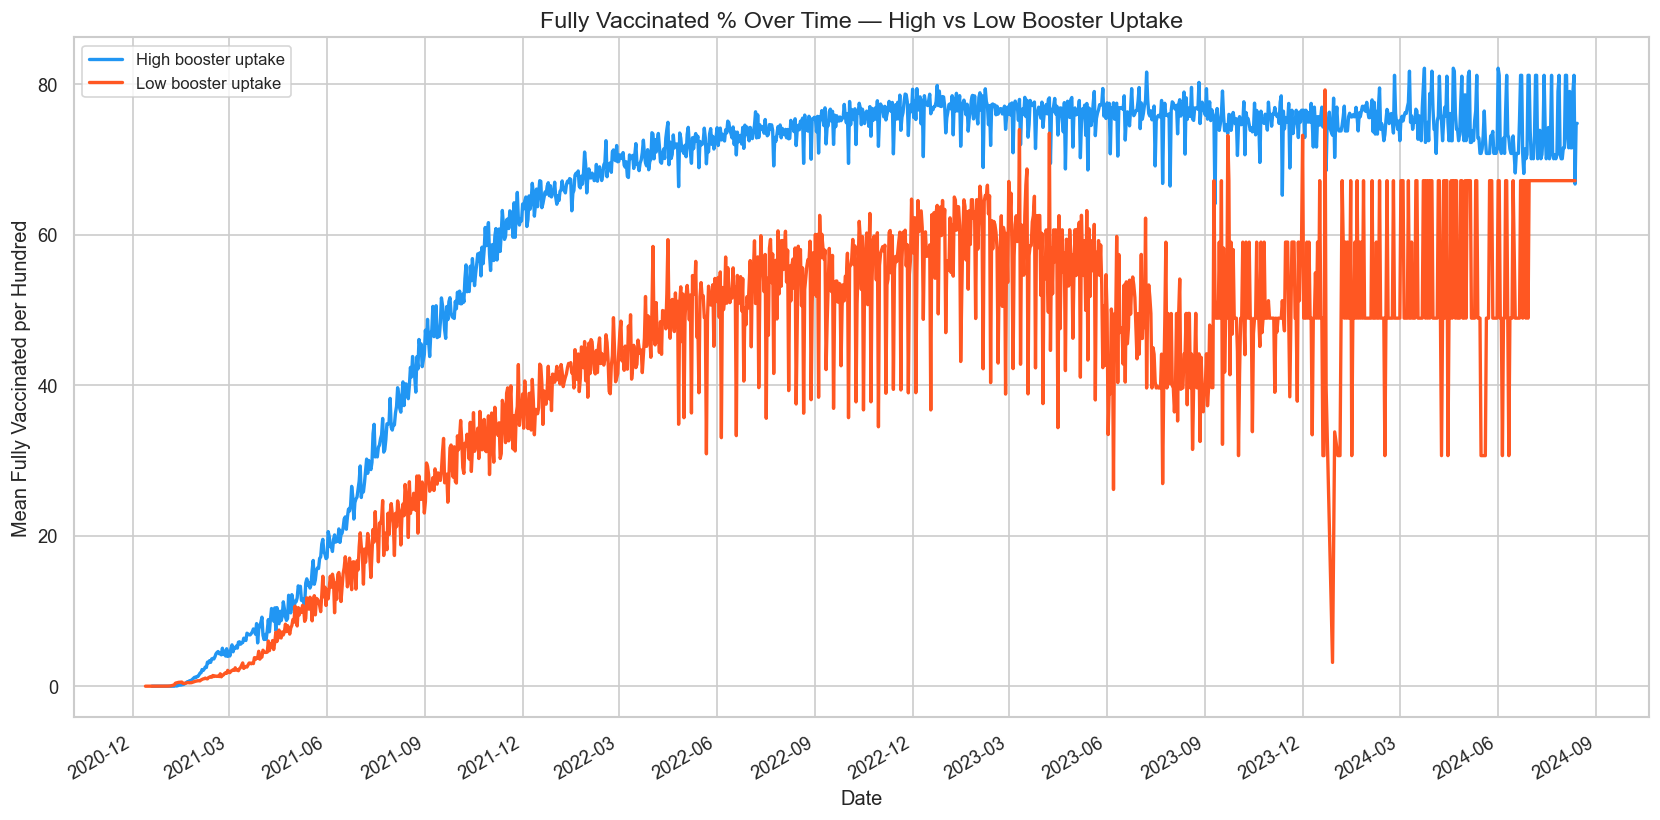

In [5]:
trend = (
    df.groupby(["date", "booster_group"])["people_fully_vaccinated_per_hundred"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
for group, color in [("High booster uptake", "#2196F3"), ("Low booster uptake", "#FF5722")]:
    chunk = trend[trend["booster_group"] == group].sort_values("date")
    ax.plot(chunk["date"], chunk["people_fully_vaccinated_per_hundred"],
            label=group, color=color, linewidth=2)

ax.set_title("Fully Vaccinated % Over Time — High vs Low Booster Uptake", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Mean Fully Vaccinated per Hundred")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "booster_group_trend.png"))
plt.show()

## 4. Scatter — booster ratio vs vaccination rate + regression

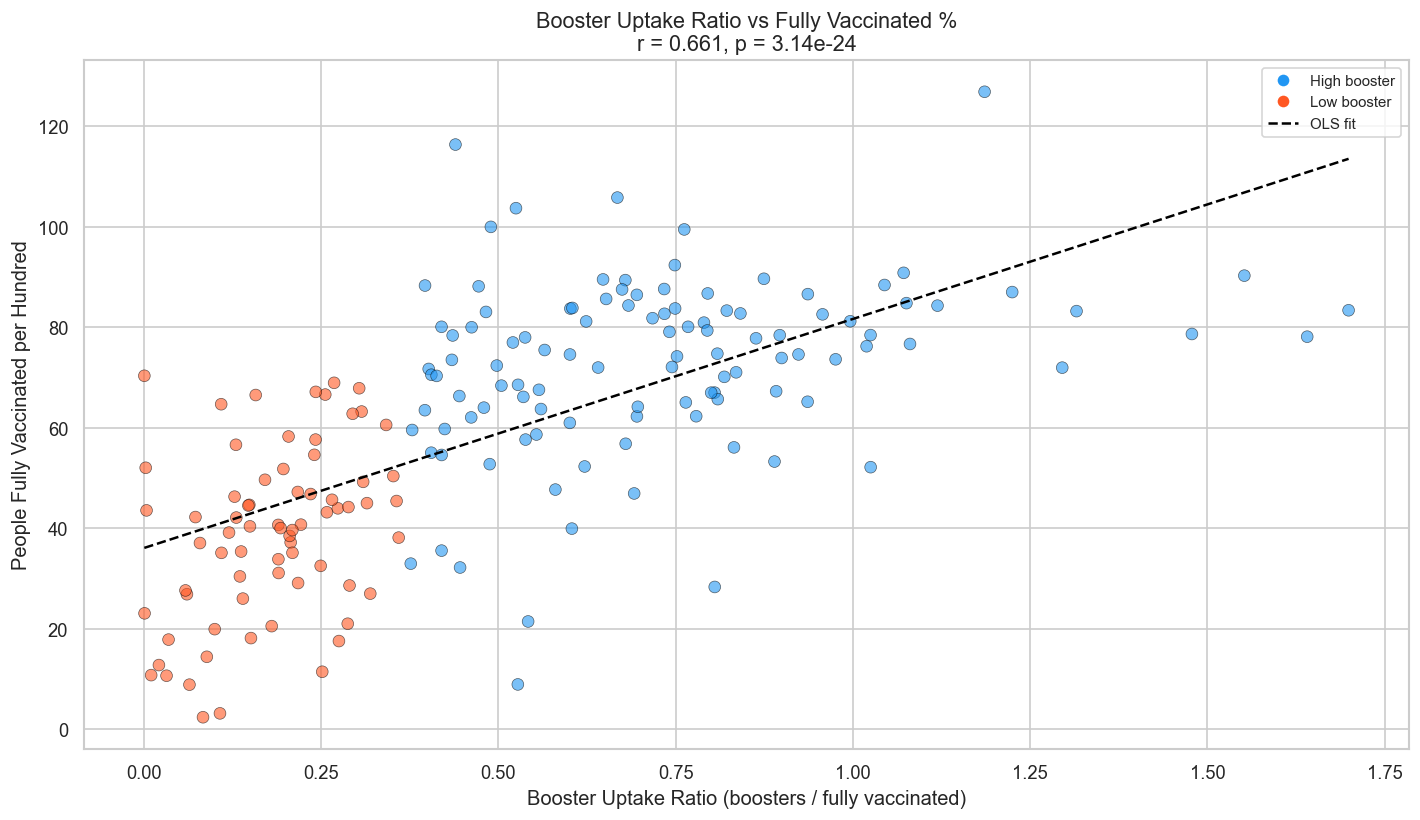

In [6]:
scatter_df = latest.dropna(subset=["booster_uptake_ratio", "people_fully_vaccinated_per_hundred"]).copy()
scatter_df = scatter_df[scatter_df["booster_uptake_ratio"] > 0]  # only countries with boosters

x = scatter_df["booster_uptake_ratio"]
y = scatter_df["people_fully_vaccinated_per_hundred"]
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(12, 7))
colors = scatter_df["booster_group"].map({
    "High booster uptake": "#2196F3",
    "Low booster uptake": "#FF5722"
})
ax.scatter(x, y, c=colors, alpha=0.6, edgecolors="black", linewidth=0.4, s=50)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="black",
        linestyle="--", linewidth=1.5, label="OLS fit")

ax.set_title(f"Booster Uptake Ratio vs Fully Vaccinated %\n"
             f"r = {r_value:.3f}, p = {p_value:.2e}", fontsize=13)
ax.set_xlabel("Booster Uptake Ratio (boosters / fully vaccinated)")
ax.set_ylabel("People Fully Vaccinated per Hundred")

# manual legend for the two groups
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2196F3", markersize=8, label="High booster"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#FF5722", markersize=8, label="Low booster"),
    Line2D([0], [0], color="black", linestyle="--", label="OLS fit"),
]
ax.legend(handles=handles, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "booster_ratio_scatter.png"))
plt.show()

## 5. Top 10 and bottom 10 by booster uptake ratio

In [7]:
ranked = latest[latest["booster_uptake_ratio"] > 0].sort_values(
    "booster_uptake_ratio", ascending=False
)

print("=== TOP 10 (highest booster uptake ratio) ===")
for _, row in ranked.head(10).iterrows():
    print(f"  {row['location']:30s}  ratio: {row['booster_uptake_ratio']:.4f}")

print(f"\n=== BOTTOM 10 (lowest booster uptake ratio) ===")
for _, row in ranked.tail(10).iterrows():
    print(f"  {row['location']:30s}  ratio: {row['booster_uptake_ratio']:.4f}")

=== TOP 10 (highest booster uptake ratio) ===
  Japan                           ratio: 1.6993
  Wales                           ratio: 1.6409
  Chile                           ratio: 1.5522
  Belgium                         ratio: 1.4783
  Guernsey                        ratio: 1.3155
  Sweden                          ratio: 1.2954
  Taiwan                          ratio: 1.2248
  Gibraltar                       ratio: 1.1858
  Peru                            ratio: 1.1194
  Argentina                       ratio: 1.0806

=== BOTTOM 10 (lowest booster uptake ratio) ===
  Jamaica                         ratio: 0.0606
  Uganda                          ratio: 0.0586
  Iraq                            ratio: 0.0347
  Syria                           ratio: 0.0319
  Equatorial Guinea               ratio: 0.0211
  Gabon                           ratio: 0.0102
  Somalia                         ratio: 0.0037
  Cape Verde                      ratio: 0.0025
  Burkina Faso                    ratio: 